# Bonus — Aluminium chain: ballistic quantum transport

Not one of the 18 official Wannier90 tutorials (no tutorial number), but a waw-native demonstration of the same **ballistic (Landauer) transport** capability the official tutorials 13/14 exercise, on a **monatomic aluminium chain** -- a one-dimensional conductor; at low temperature its conductance is **quantized**, $G = G_0\,T(E_F)$ with $G_0 = 2e^2/h$, where $T(E)$ counts the number of conducting channels (bands crossing the energy $E$).

The Wannier tight-binding $H(R)$ along the chain is exactly the input the **Landauer** Green's-function transport method needs (`waw.analysis.transport.transport_bulk`, Lopez-Sancho decimation). This is a 1-D system in a transverse vacuum, so — like any slab/chain — the out-of-plane Wannier spread is unconstrained by the finite-difference mesh; we use **`guiding_centres=True`** to pin the WF centres and keep the localisation well-behaved.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged DFT of the chain
One Al atom per cell, spacing $d = 2.5$ Å along $z$, with 12 Å of vacuum in $x,y$. The chain is metallic (cold smearing); the $k$-mesh is dense **along the chain only** — `mp_grid = (1, 1, 8)`.

In [2]:
from ase import Atoms
from waw.interfaces.ase.structure import real_lattice
from waw.analysis import transport_bulk
from waw.units import ANG_TO_BOHR, EV_TO_HARTREE

d = 2.5
atoms = Atoms('Al', positions=[[0, 0, 0]],
              cell=[[12, 0, 0], [0, 12, 0], [0, 0, d]], pbc=True)
MP_GRID = (1, 1, 8)
WORK = HERE / 'runs' / 'alchain'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.02)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'alchain',
    ecutwfc=45, scf_kpts=(1, 1, 16), nbnd=12, num_wann=4,
    scdm_entanglement='erfc', scdm_mu=5.0, scdm_sigma=4.0,
    system_extra=SMEAR, pseudopotentials={'Al': 'Al.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/alchain/ if present
)
E_FERMI = ov['fermi_energy']            # eV, read from the SCF by qe.py
print(f'E_F = {E_FERMI:.3f} eV')

E_F = -3.599 eV


### 2. Wannierise (4 $s$+$p$ MLWFs, guiding centres)
Four MLWFs (one $s$-like, three $p$-like) span the bands around $E_F$. `guiding_centres=True` keeps them centred on the atom despite the transverse vacuum.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=4,
    outer_window=(-1e3, E_FERMI + 12), frozen_window=(-1e3, E_FERMI - 6),
    guiding_centres=True, n_restarts=3, dis_n_iter=1000, n_iter=6000,
    verbose=False,
)
print(f'Omega_I = {result.dis.omega_i*BOHR_TO_ANG**2:.3f} Ang^2, '
      f'Omega_total = {result.omega_final*BOHR_TO_ANG**2:.3f} Ang^2 '
      f'(well-controlled thanks to guiding_centres)')

Omega_I = 8.036 Ang^2, Omega_total = 10.254 Ang^2 (well-controlled thanks to guiding_centres)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

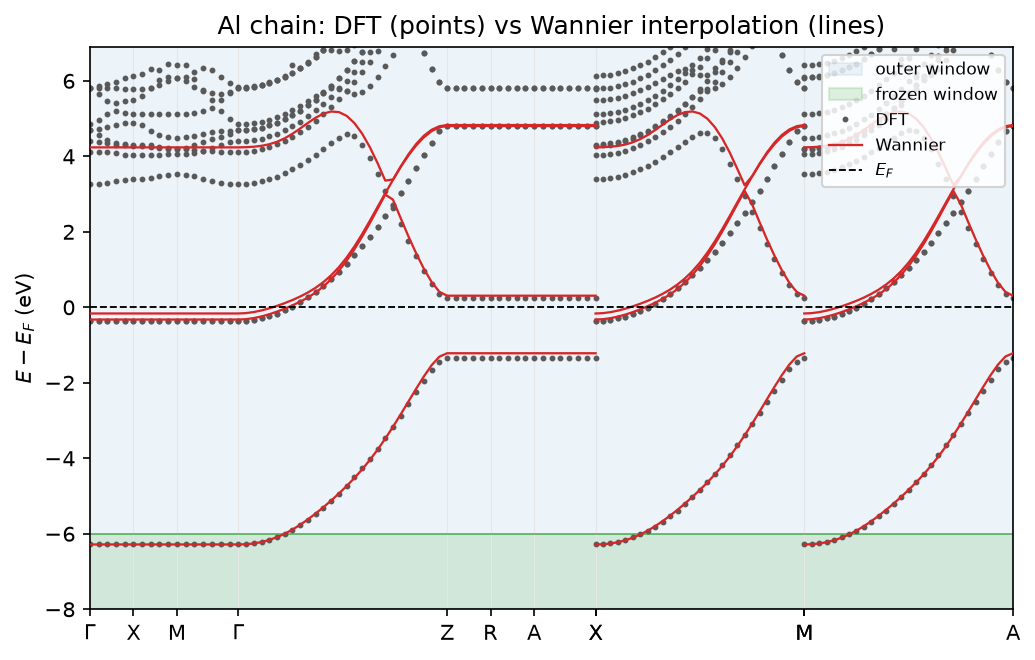

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 1 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'alchain', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, E_FERMI + 12), frozen_window=(-1e3, E_FERMI - 6), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Al chain: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, E_FERMI - 6), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 3. Landauer transmission $T(E)$
`transport_bulk` builds the semi-infinite chain from $H(R)$ and computes the transmission by Green's-function decimation. In a **perfect periodic** conductor $T(E)$ is exactly the **integer number of bands at energy $E$** — a conductance staircase. The value at $E_F$ is the number of open channels of the ideal chain.

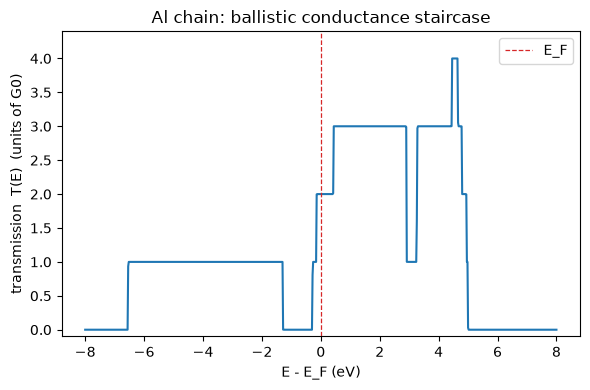

conductance at E_F: G = 2.00 G0  (2 open channels; G0 = 2e^2/h = 77.5 uS)


In [5]:
tr = transport_bulk(
    result.hr, real_lattice(atoms), result.centres_bohr, mp_grid=MP_GRID,
    one_dim_axis='z', dist_cutoff=6.0 * ANG_TO_BOHR,
    fermi_energy=E_FERMI * EV_TO_HARTREE,
    energy_window=(-8.0 * EV_TO_HARTREE, 8.0 * EV_TO_HARTREE),
    energy_step=0.02 * EV_TO_HARTREE, translate_home_cell=True,
)
E = tr.energies * HARTREE_TO_EV        # relative to E_F
T = tr.transmission

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(E, T, 'C0', lw=1.5)
ax.axvline(0.0, color='C3', lw=0.9, ls='--', label='E_F')
ax.set_xlabel('E - E_F (eV)'); ax.set_ylabel('transmission  T(E)  (units of G0)')
ax.set_title('Al chain: ballistic conductance staircase')
ax.set_ylim(-0.1, T.max() + 0.4); ax.legend()
plt.tight_layout(); plt.show()

T_EF = float(T[np.argmin(np.abs(E))])
print(f'conductance at E_F: G = {T_EF:.2f} G0  ({T_EF:.0f} open channels; '
      f'G0 = 2e^2/h = 77.5 uS)')

The transmission is a clean integer staircase — each step is a band entering the transport window — and at $E_F$ the ideal Al chain has a well-defined number of conducting channels. (For a **device** with a scattering region between leads, `waw.analysis.transport.transport_lcr` computes the same Landauer transmission through a left-centre-right junction.)

**Takeaway.** The Wannier $H(R)$ turns a converged DFT chain into a quantum-transport calculation: the Landauer conductance staircase of a 1-D aluminium wire, waw-native, with `guiding_centres` handling the transverse-vacuum geometry.